## Introduction for monte carlo simulation

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

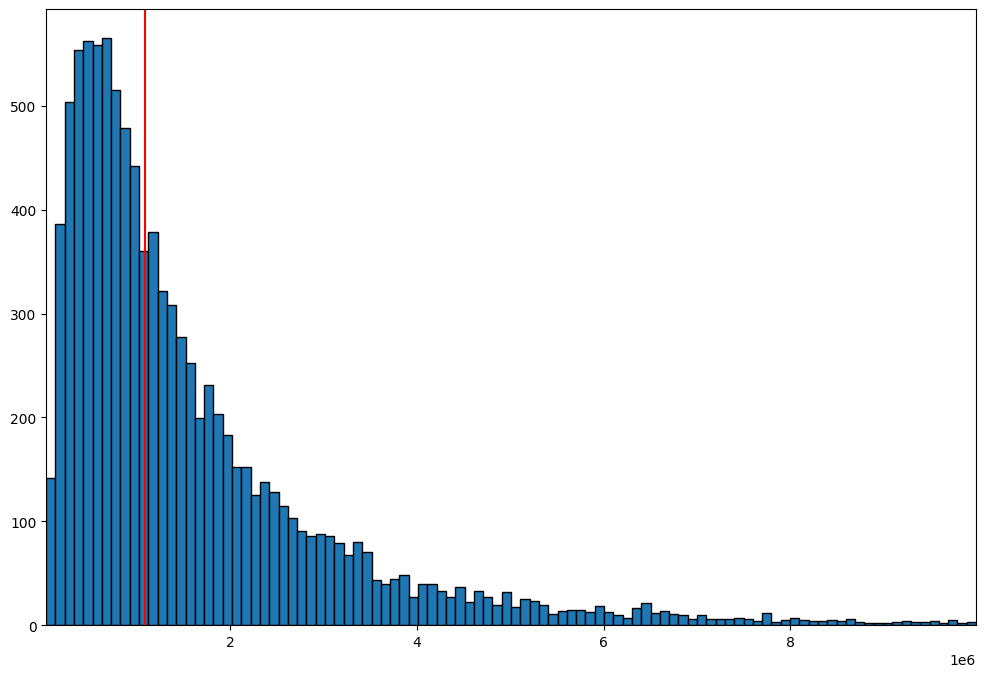

In [57]:
pv = 100000
er = .095
time_horizon = 30
ending_balance = 0
volatility = .187
for year in range(1, 30 + 1):
    year_return = np.random.normal(er, volatility)
    ending_balance = pv * (1 + year_return)
    pv = ending_balance
    ##print("{:<10d} {:>15,.0f}".format(year, ending_balance))

def monte_carlo_simulation(iterations, vol, pv, returns_mean):
    horizon = 30
    returns = np.random.normal(returns_mean, vol, size=(iterations, horizon))
    portfolio = np.zeros((iterations, horizon))
    for i in range(iterations):
        balance = pv
        for y in range(horizon):
            balance = balance * (1 + returns[i, y])
            portfolio[i, y] = balance
    portfolio = pd.DataFrame(portfolio.T)
    end = portfolio.iloc[29]
    mask = end < 10000000
    plt.figure(figsize = (12,8))
    plt.xlim(end[mask].min(), end[mask].max())
    plt.hist(end[mask], bins=100, edgecolor='k')
    plt.axvline(end[mask].median(), color='r')
monte_carlo_simulation(10000, .1832, 100000, .0987)